In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from torchvision.models import resnet50, ResNet50_Weights

from IntegratedGradients import IntegratedGradients

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights).to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [3]:
preprocess = weights.transforms()

In [4]:
img = Image.open("../Pictures/Indian_Cobra.jpg").convert("RGB")
input_tensor = preprocess(img).unsqueeze(0).to(device)

In [5]:
with torch.no_grad():
    output = model(input_tensor)
    probs = torch.nn.functional.softmax(output, dim=1)

pred_class = torch.argmax(probs, dim=1).item()
confidence = probs[0, pred_class].item()

print("Predicted class:", pred_class)
print("Confidence:", confidence)

labels = weights.meta["categories"]
print("Class name:", labels[pred_class])

Predicted class: 63
Confidence: 0.32439595460891724
Class name: Indian cobra


In [6]:
ig = IntegratedGradients(model, device=device)

baseline = torch.zeros_like(input_tensor)
steps = 200

attributions = ig.explain(
    inputs=input_tensor,
    target=pred_class,
    baseline=baseline,
    steps=steps
)

In [7]:
ig_map = attributions.abs().sum(dim=1, keepdim=True)
ig_map = ig_map - ig_map.min()
ig_map = ig_map / (ig_map.max() + 1e-8)

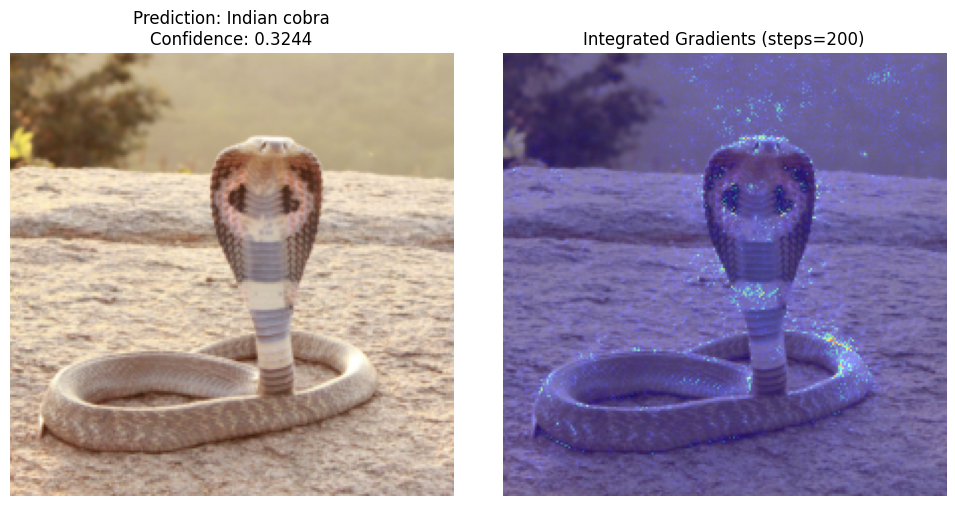

In [8]:
def denormalize_for_display(t, weights):
    mean = torch.tensor(weights.transforms().mean).view(1,3,1,1).to(t.device)
    std = torch.tensor(weights.transforms().std).view(1,3,1,1).to(t.device)
    x = (t * std) + mean
    x = x.clamp(0, 1)
    x = (x[0].permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8)
    return x

def to_numpy_heatmap(hm):
    return hm[0,0].detach().cpu().numpy()

def overlay(img_uint8, hm, alpha=0.45):
    hm_rgba = plt.get_cmap("jet")(hm)
    hm_rgb = (hm_rgba[..., :3] * 255).astype(np.uint8)
    return (img_uint8 * (1 - alpha) + hm_rgb * alpha).astype(np.uint8)

img_disp = denormalize_for_display(input_tensor, weights)
ig_hm = to_numpy_heatmap(ig_map)
ig_overlay = overlay(img_disp, ig_hm, alpha=0.45)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_disp)
plt.title(f"Prediction: {labels[pred_class]}\nConfidence: {confidence:.4f}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(ig_overlay)
plt.title(f"Integrated Gradients (steps={steps})")
plt.axis("off")

plt.tight_layout()
plt.show()

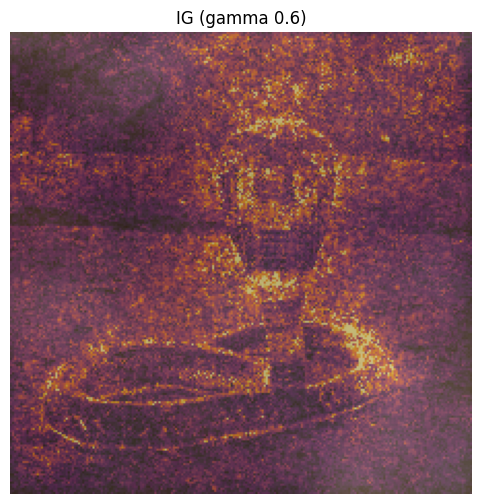

In [10]:
heat = ig_to_heatmap(attributions, mode="abs", clip_percentile=99.0)
heat = heat ** 0.6   # gamma < 1 zvýrazní slabšie oblasti
show_overlay(img, heat, title="IG (gamma 0.6)", alpha=0.5, cmap="inferno")